# What Factors Influence How Severe a Delay Is?

### Author
Imran Qureshi

### Notebook Overview
This notebook focuses specifically on predicting the number of delay days associated with shipments using regression-based analytical techniques in R. The analysis evaluates operational, transportation-related, route-related, and disruption-related variables associated with the severity of shipment delays.


# Exploratory Data Analysis (EDA)

Initial exploratory data analysis was performed to better understand the distributions and variation of shipment-related variables before regression modeling. Histograms and summary statistics were used to evaluate patterns associated with the number of delay days across shipments.


Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Loading required package: lattice

Warning message:
"package 'lattice' was built under R version 4.5.3"

Attaching package: 'kknn'


The following object is masked from 'package:caret':

    contr.dummy


Warning message:
"package 'rpart' was built under R version 4.5.3"
Warning message:
"package 'rpart.plot' was built under R version 4.5.2"
Warning message:
"package 'skimr' was built under R version 4.5.2"
Warning message:
"package 'psych' was built under R version 4.5.3"

Attaching package: 'psych'


The following objects are masked from 'package:ggplot2':

    %+%, alpha




'data.frame':	10000 obs. of  19 variables:
 $ Order_Date              : chr  "1/4/2024" "1/4/2024" "1/4/2024" "1/4/2024" ...
 $ Origin_City             : chr  "Tokyo, JP" "Shanghai, CN" "Santos, BR" "Tokyo, JP" ...
 $ Destination_City        : chr  "Singapore, SG" "Los Angeles, US" "Shanghai, CN" "Singapore, SG" ...
 $ Route_Type              : chr  "Intra-Asia" "Pacific" "Commodity" "Intra-Asia" ...
 $ Transportation_Mode     : chr  "Sea" "Sea" "Sea" "Sea" ...
 $ Product_Category        : chr  "Perishable Foods" "Textiles" "Consumer Electronics" "Perishable Foods" ...
 $ Base_Lead_Time_Days     : int  7 18 35 7 7 28 24 35 7 12 ...
 $ Scheduled_Lead_Time_Days: int  10 19 38 8 10 31 27 37 9 15 ...
 $ Actual_Lead_Time_Days   : int  10 18 35 7 7 27 24 35 7 12 ...
 $ Delay_Days              : int  0 -1 -3 -1 -3 -4 -3 -2 -2 -3 ...
 $ Delivery_Status         : chr  "On Time" "On Time" "On Time" "On Time" ...
 $ Disruption_Event        : chr  "Port Congestion" "None" "None" "None" ...
 $ Geop

   Order_Date         Origin_City        Destination_City        Route_Type  
 Min.   :2024-01-04   Length:10000       Length:10000       Atlantic  :1701  
 1st Qu.:2024-07-01   Class :character   Class :character   Commodity :1608  
 Median :2024-12-27   Mode  :character   Mode  :character   Intra-Asia:1634  
 Mean   :2024-12-29                                         Pacific   :1645  
 3rd Qu.:2025-07-01                                         Suez      :3412  
 Max.   :2026-01-03                                                          
                                                                             
 Transportation_Mode             Product_Category Base_Lead_Time_Days
 Air:1729            Auto Parts          :1416    Min.   : 2.00      
 Sea:8271            Consumer Electronics:1458    1st Qu.: 7.00      
                     Perishable Foods    :1402    Median :18.00      
                     Pharmaceuticals     :1432    Mean   :17.51      
                     Raw M

,skim_type,skim_variable,n_missing,complete_rate,Date.min,Date.max,Date.median,Date.n_unique,character.min,character.max,⋯,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<date>,<date>,<date>,<int>,<int>,<int>,⋯,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Date,Order_Date,0,1,2024-01-04,2026-01-03,2024-12-27,731,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,Origin_City,0,1,NA,NA,NA,NA,9,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,character,Destination_City,0,1,NA,NA,NA,NA,12,15,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,character,Disruption_Event,0,1,NA,NA,NA,NA,4,39,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,character,Cost..USD....per.Kg,0,1,NA,NA,NA,NA,5,6,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,character,Mitigation_Action_Taken,0,1,NA,NA,NA,NA,10,21,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7,factor,Route_Type,0,1,NA,NA,NA,NA,NA,NA,⋯,5,"Sue: 3412, Atl: 1701, Pac: 1645, Int: 1634",NA,NA,NA,NA,NA,NA,NA,NA
8,factor,Transportation_Mode,0,1,NA,NA,NA,NA,NA,NA,⋯,2,"Sea: 8271, Air: 1729",NA,NA,NA,NA,NA,NA,NA,NA
9,factor,Product_Category,0,1,NA,NA,NA,NA,NA,NA,⋯,7,"Con: 1458, Sem: 1454, Tex: 1440, Pha: 1432",NA,NA,NA,NA,NA,NA,NA,NA


Warning message in FUN(newX[, i], ...):
"no non-missing arguments to min; returning Inf"
Warning message in FUN(newX[, i], ...):
"no non-missing arguments to max; returning -Inf"


,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Order_Date,1,10000,NaN,NA,NA,NaN,NA,Inf,-Inf,-Inf,NA,NA,NA
Origin_City*,2,10000,3.48390,1.712727e+00,3.00,3.479875,2.965200,1.00,6.00,5.00,0.006916537,-1.28325223,1.712727e-02
Destination_City*,3,10000,3.47550,1.704902e+00,3.00,3.469375,1.482600,1.00,6.00,5.00,0.016629616,-1.25677934,1.704902e-02
Route_Type*,4,10000,3.34590,1.500359e+00,4.00,3.432375,1.482600,1.00,5.00,4.00,-0.297444281,-1.36879359,1.500359e-02
Transportation_Mode*,5,10000,1.82710,3.781797e-01,2.00,1.908875,0.000000,1.00,2.00,1.00,-1.729692432,0.99193513,3.781797e-03
Product_Category*,6,10000,4.00600,2.003888e+00,4.00,4.007500,2.965200,1.00,7.00,6.00,-0.001376106,-1.25906328,2.003888e-02
Base_Lead_Time_Days,7,10000,17.50990,1.090284e+01,18.00,17.243000,14.826000,2.00,35.00,33.00,0.119579420,-1.26408520,1.090284e-01
Scheduled_Lead_Time_Days,8,10000,19.50320,1.093356e+01,20.00,19.222625,14.826000,3.00,38.00,35.00,0.118885537,-1.25357932,1.093356e-01
Actual_Lead_Time_Days,9,10000,18.70430,1.166282e+01,18.00,18.321875,14.826000,1.00,49.00,48.00,0.237929727,-1.00573881,1.166282e-01


null device 
          1

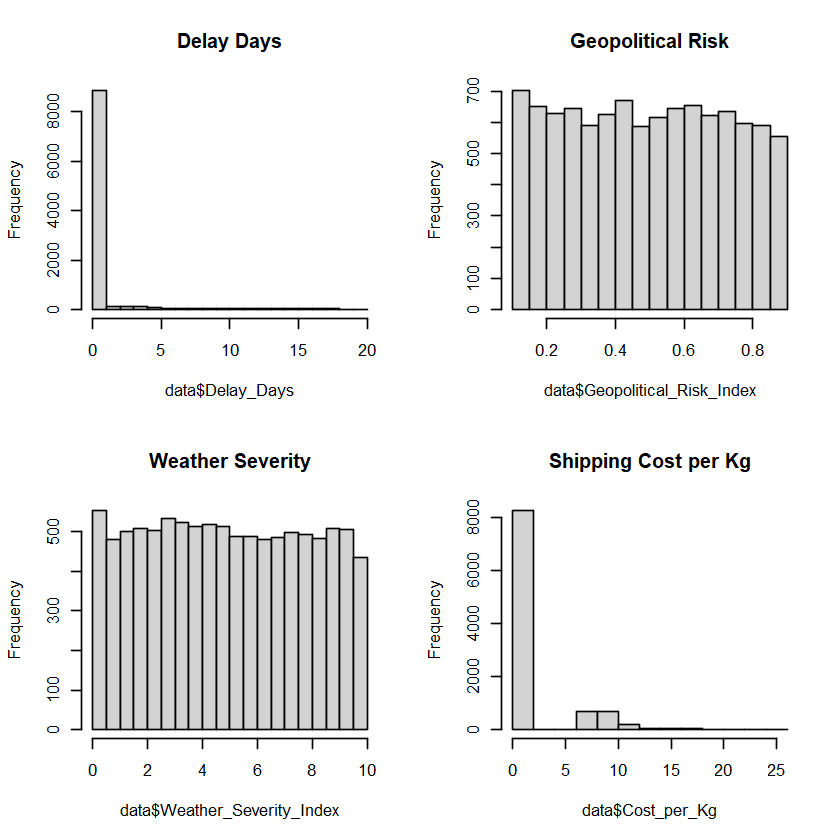

In [1]:
library(caret)
library(kknn)
library(rpart)
library(rpart.plot)
library(skimr)
library(psych)

data <- read.csv("C:/Users/iqure/Downloads/IT 190 Project - Imran Qureshi - Data.csv")
str(data)

data$Shipping_Cost_USD <- as.numeric(gsub("[^0-9.]", "", data$Shipping_Cost_USD))
data$Cost_per_Kg <- as.numeric(gsub("[^0-9.]", "", data$Cost..USD....per.Kg))
data$Order_Date <- as.Date(data$Order_Date, format = "%m/%d/%Y")
data$Delay_Days[data$Delay_Days < 0] <- 0

data$Delivery_Status <- factor(data$Delivery_Status)
data$Route_Type <- factor(data$Route_Type)
data$Product_Category <- factor(data$Product_Category)
data$Transportation_Mode <- factor(data$Transportation_Mode)

summary(data)
skim(data)
psych::describe(data)

par(mfrow=c(2,2))
hist(data$Delay_Days, main = "Delay Days")
hist(data$Geopolitical_Risk_Index, main = "Geopolitical Risk")
hist(data$Weather_Severity_Index, main = "Weather Severity")
hist(data$Cost_per_Kg, main = "Shipping Cost per Kg")
dev.off()


Initial exploratory analysis revealed that certain trade routes, particularly the Suez route, appeared more frequently among shipments experiencing higher delay values.

# k-Nearest Neighbors (kNN)

A k-nearest neighbors regression model was developed to predict the number of delay days for each shipment. Numerical variables were normalized prior to training to ensure equal weighting during distance calculations.


Base kNN RMSE: 2.738759 
Base kNN MAE: 1.113067 
Base kNN R-squared: 0.2665796 
k-Nearest Neighbors 

7000 samples
   7 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 5600, 5600, 5600, 5600, 5600 
Resampling results across tuning parameters:

  kmax  RMSE      Rsquared   MAE      
   5    2.607382  0.3315993  0.8960714
   7    2.607382  0.3315993  0.8960714
   9    2.607382  0.3315993  0.8960714
  11    2.607382  0.3315993  0.8960714
  13    2.607382  0.3315993  0.8960714
  15    2.607382  0.3315993  0.8960714
  17    2.607382  0.3315993  0.8960714
  19    2.607382  0.3315993  0.8960714
  21    2.607382  0.3315993  0.8960714
  23    2.607382  0.3315993  0.8960714
  25    2.607382  0.3315993  0.8960714

Tuning parameter 'distance' was held constant at a value of 2
Tuning
 parameter 'kernel' was held constant at a value of rectangular
RMSE was used to select the optimal model using the smallest value.
The final values used for the model were k

,kmax,distance,kernel
,<dbl>,<dbl>,<fct>
11,25,2,rectangular


Best kNN RMSE: 2.839313 
Best kNN MAE: 1.37696 
Best kNN R-squared: 0.2321612 


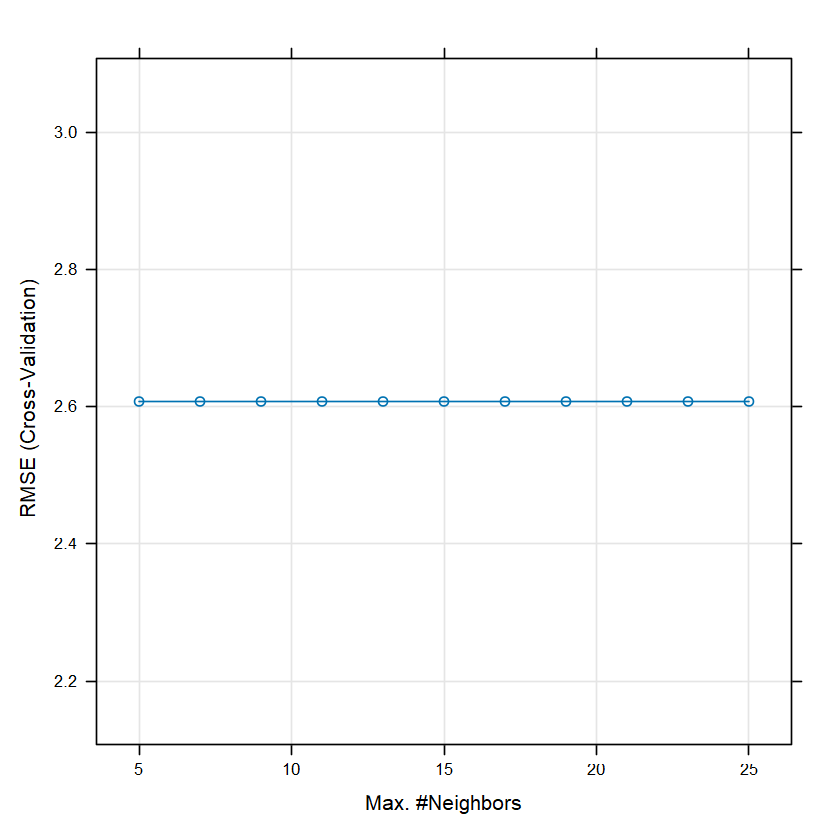

In [2]:
data$Cost_per_Kg_numeric <- data$Cost_per_Kg

data$Cost_per_Kg <- cut(
  data$Cost_per_Kg,
  breaks = c(0, 5, Inf),
  labels = c("Low","High"),
  include.lowest = TRUE
)

data$Cost_per_Kg <- factor(data$Cost_per_Kg, levels = c("Low", "High"))

data$Geopolitical_Risk_Index <- cut(
  data$Geopolitical_Risk_Index,
  breaks = c(0, 0.25, 0.5, 0.75, 1),
  labels = c("Low", "Moderate", "High", "Very High"),
  include.lowest = TRUE
)

data$Geopolitical_Risk_Index <- factor(data$Geopolitical_Risk_Index, levels = c("Low", "Moderate", "High", "Very High"))

set.seed(123)
train_indices <- createDataPartition(data$Delay_Days, p = 0.7, list = FALSE)
train_data <- data[train_indices, ]
test_data  <- data[-train_indices, ]

train_data$Cost_per_Kg_numeric <- log(train_data$Cost_per_Kg_numeric)
test_data$Cost_per_Kg_numeric  <- log(test_data$Cost_per_Kg_numeric)

scaler <- preProcess(
  train_data[, c("Weather_Severity_Index",
                 "Inflation_Rate_Pct", "Cost_per_Kg_numeric")],
  method = c("center", "scale")
)

normalized_columns <- c("Weather_z",
                        "Inflation_z", "Cost_per_Kg_numeric_z")

train_data[normalized_columns] <- predict(
  scaler, train_data[, c("Weather_Severity_Index",
                         "Inflation_Rate_Pct", "Cost_per_Kg_numeric")]
)

test_data[normalized_columns] <- predict(
  scaler, test_data[, c("Weather_Severity_Index",
                        "Inflation_Rate_Pct", "Cost_per_Kg_numeric")]
)

k_neighbors <- 5
distance_metric  <- 2
kernel_type  <- "rectangular"

knn_base_model <- kknn(
  Delay_Days ~ Weather_z + Geopolitical_Risk_Index +
    Inflation_z + Cost_per_Kg_numeric_z + Route_Type + Product_Category + Transportation_Mode,
  train    = train_data,
  test     = test_data,
  k        = k_neighbors,
  distance = distance_metric,
  kernel   = kernel_type
)

test_data$knn_base_pred <- fitted(knn_base_model)

knn_base_rmse <- RMSE(test_data$knn_base_pred, test_data$Delay_Days)
knn_base_mae <- MAE(test_data$knn_base_pred, test_data$Delay_Days)
knn_base_r2 <- R2(test_data$knn_base_pred, test_data$Delay_Days)

cat("Base kNN RMSE:", knn_base_rmse, "\n")
cat("Base kNN MAE:", knn_base_mae, "\n")
cat("Base kNN R-squared:", knn_base_r2, "\n")

cv_control <- trainControl(method = "cv", number = 5)

knn_grid <- expand.grid(
  kmax     = seq(5, 25, by = 2),
  distance = c(2),
  kernel   = c("rectangular")
)

set.seed(42)
knn_cv_model <- train(
  Delay_Days ~ Weather_z +
    Inflation_z + Cost_per_Kg_numeric_z + Geopolitical_Risk_Index +
    Route_Type + Product_Category + Transportation_Mode,
  data      = train_data,
  method    = "kknn",
  tuneGrid  = knn_grid,
  trControl = cv_control,
  metric    = "RMSE"
)

print(knn_cv_model)
plot(knn_cv_model)

best_knn_params <- knn_cv_model$bestTune
best_knn_params

knn_best_model <- kknn(
  Delay_Days ~ Weather_z + Geopolitical_Risk_Index +
    Inflation_z + Cost_per_Kg_numeric_z +
    Route_Type + Product_Category + Transportation_Mode,
  train    = train_data,
  test     = test_data,
  k        = best_knn_params$kmax,
  distance = best_knn_params$distance,
  kernel   = as.character(best_knn_params$kernel)
)

test_data$knn_best_pred <- fitted(knn_best_model)

knn_best_rmse <- RMSE(test_data$knn_best_pred, test_data$Delay_Days)
knn_best_mae <- MAE(test_data$knn_best_pred, test_data$Delay_Days)
knn_best_r2 <- R2(test_data$knn_best_pred, test_data$Delay_Days)

cat("Best kNN RMSE:", knn_best_rmse, "\n")
cat("Best kNN MAE:", knn_best_mae, "\n")
cat("Best kNN R-squared:", knn_best_r2, "\n")


The kNN regression model demonstrated moderate predictive capability when estimating shipment delay values using combinations of operational and disruption-related variables.

# Decision Tree Analysis

Decision trees were used to identify the strongest branching variables associated with delay severity. This approach improved interpretability by visually displaying the sequence of conditions associated with higher and lower numbers of delay days.


Call:
rpart(formula = Delay_Days ~ Geopolitical_Risk_Index + Weather_Severity_Index + 
    Inflation_Rate_Pct + Cost_per_Kg + Route_Type + Product_Category + 
    Transportation_Mode, data = train_data, method = "anova", 
    control = rpart.control(cp = 1e-04, minsplit = 20, minbucket = 10, 
        maxdepth = 3))
  n= 7000 

            CP nsplit rel error    xerror       xstd
1 0.0528729451      0 1.0000000 1.0001855 0.04868126
2 0.0028487938      1 0.9471271 0.9473562 0.04248001
3 0.0011769440      3 0.9414295 0.9542781 0.04278217
4 0.0003694518      4 0.9402525 0.9596883 0.04300771
5 0.0003472920      5 0.9398831 0.9600602 0.04300484
6 0.0001861548      6 0.9395358 0.9594786 0.04299192
7 0.0001000000      7 0.9393496 0.9594685 0.04299058

Variable importance
             Route_Type        Product_Category  Weather_Severity_Index 
                     87                       7                       3 
Geopolitical_Risk_Index      Inflation_Rate_Pct 
                      2        

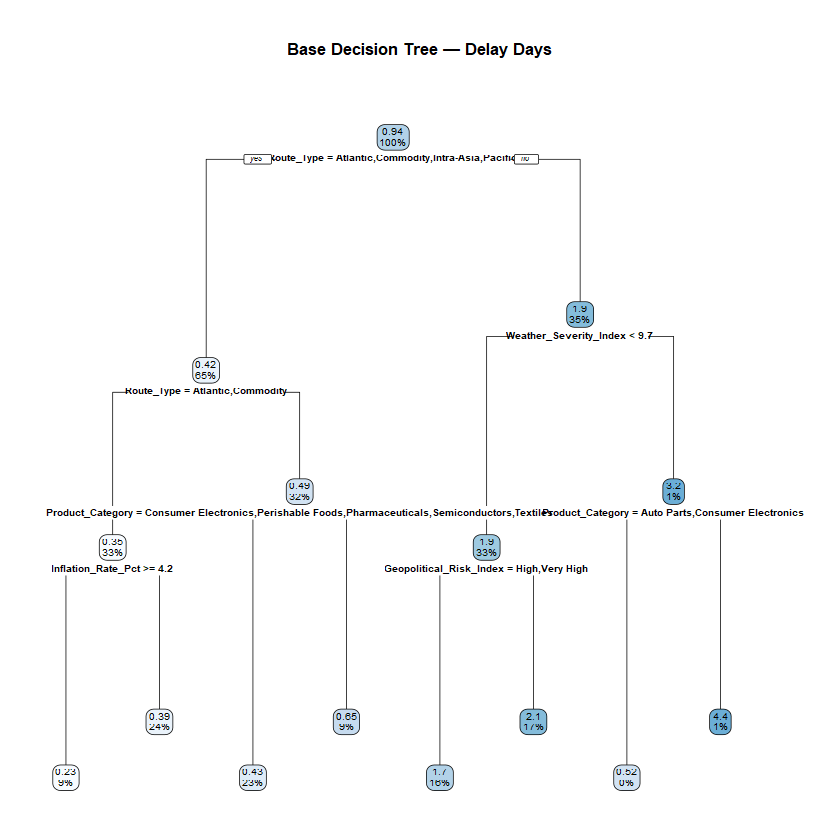

,cp
,<dbl>
10,0.046



Regression tree:
rpart(formula = Delay_Days ~ Geopolitical_Risk_Index + Weather_Severity_Index + 
    Inflation_Rate_Pct + Cost_per_Kg + Route_Type + Product_Category + 
    Transportation_Mode, data = train_data, method = "anova", 
    control = rpart.control(cp = 1e-04, minsplit = 10, minbucket = 5, 
        maxdepth = 4))

Variables actually used in tree construction:
[1] Route_Type

Root node error: 67200/7000 = 9.6

n= 7000 

        CP nsplit rel error  xerror     xstd
1 0.052873      0   1.00000 1.00030 0.048687
2 0.046000      1   0.94713 0.94788 0.042503


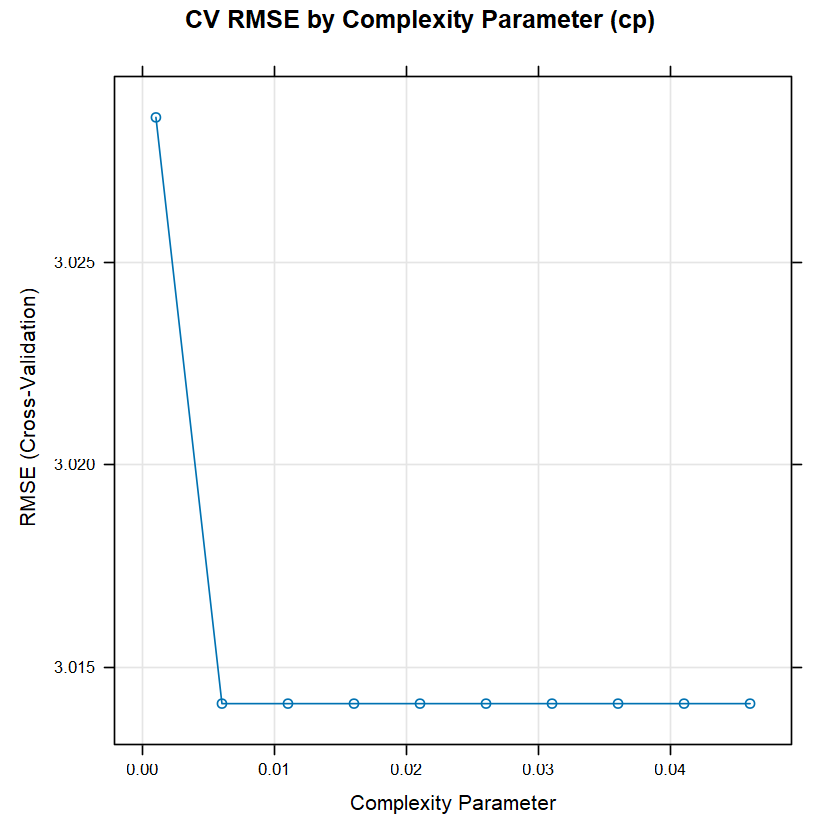

Call:
rpart(formula = Delay_Days ~ Geopolitical_Risk_Index + Weather_Severity_Index + 
    Inflation_Rate_Pct + Cost_per_Kg + Route_Type + Product_Category + 
    Transportation_Mode, data = train_data, method = "anova", 
    control = rpart.control(cp = 1e-04, minsplit = 10, minbucket = 5, 
        maxdepth = 4))
  n= 7000 

          CP nsplit rel error    xerror       xstd
1 0.05287295      0 1.0000000 1.0003046 0.04868717
2 0.04600000      1 0.9471271 0.9478833 0.04250347

Variable importance
Route_Type 
       100 

Node number 1: 7000 observations,    complexity param=0.05287295
  mean=0.9378571, MSE=9.599995 
  left son=2 (4577 obs) right son=3 (2423 obs)
  Primary splits:
      Route_Type              splits as  LLLLR,     improve=0.0528729500, (0 missing)
      Geopolitical_Risk_Index splits as  RRLL,      improve=0.0005846157, (0 missing)
      Product_Category        splits as  RLLLRRR,   improve=0.0004893057, (0 missing)
      Weather_Severity_Index  < 9.65  to the left,  i

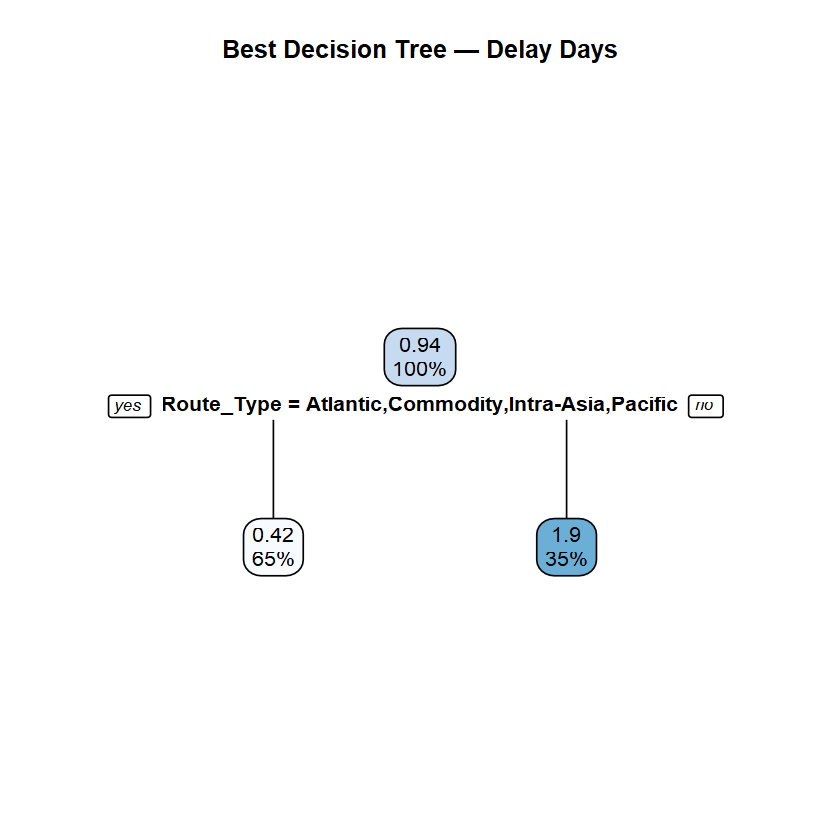

In [3]:
dt_base_model <- rpart(
  Delay_Days ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost_per_Kg +
    Route_Type + Product_Category + Transportation_Mode,
  data    = train_data,
  method  = "anova",
  control = rpart.control(
    cp        = 0.0001,
    minsplit  = 20,
    minbucket = 10,
    maxdepth  = 3
  )
)

rpart.plot(dt_base_model, main = "Base Decision Tree — Delay Days")
summary(dt_base_model)

test_data$dt_base_pred <- predict(dt_base_model, test_data)

dt_base_rmse <- RMSE(test_data$dt_base_pred, test_data$Delay_Days)
dt_base_mae <- MAE(test_data$dt_base_pred, test_data$Delay_Days)
dt_base_r2 <- R2(test_data$dt_base_pred, test_data$Delay_Days)

cat("Base Decision Tree RMSE:", dt_base_rmse, "\n")
cat("Base Decision Tree MAE:", dt_base_mae, "\n")
cat("Base Decision Tree R-squared:", dt_base_r2, "\n")

dt_grid <- expand.grid(
  cp = seq(0.001, 0.050, by = 0.005)
)

set.seed(42)
dt_cv_model <- train(
  Delay_Days ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost_per_Kg +
    Route_Type + Product_Category + Transportation_Mode,
  data      = train_data,
  method    = "rpart",
  tuneGrid  = dt_grid,
  trControl = cv_control,
  control   = rpart.control(
    minsplit  = 20,
    minbucket = 10,
    maxdepth  = 3
  ),
  metric    = "RMSE"
)

print(dt_cv_model)
plot(dt_cv_model, main = "CV RMSE by Complexity Parameter (cp)")

best_dt_params <- dt_cv_model$bestTune
best_dt_params

dt_best_model <- rpart(
  Delay_Days ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost_per_Kg +
    Route_Type + Product_Category + Transportation_Mode,
  data    = train_data,
  method  = "anova",
  control = rpart.control(
    cp = .0001,
    minsplit = 10,
    minbucket = 5,
    maxdepth = 4)
)

dt_best_model <- prune(dt_best_model, cp = best_dt_params$cp)

printcp(dt_best_model)

rpart.plot(dt_best_model, main = "Best Decision Tree — Delay Days")
summary(dt_best_model)

test_data$dt_best_pred <- predict(dt_best_model, test_data)

dt_best_rmse <- RMSE(test_data$dt_best_pred, test_data$Delay_Days)
dt_best_mae <- MAE(test_data$dt_best_pred, test_data$Delay_Days)
dt_best_r2 <- R2(test_data$dt_best_pred, test_data$Delay_Days)

cat("Best Decision Tree RMSE:", dt_best_rmse, "\n")
cat("Best Decision Tree MAE:", dt_best_mae, "\n")
cat("Best Decision Tree R-squared:", dt_best_r2, "\n")


The decision tree regression model revealed that route type emerged as the strongest predictor of shipment delay severity, with the Suez Canal consistently acting as a major bottleneck for extended disruptions.

# Model Summary Comparison

The final comparison evaluates how well the kNN and decision tree models predicted the number of delay days across shipments.


In [4]:
cat("\n=== Best kNN Model Performance ===\n")
cat("RMSE:      ", knn_best_rmse, "\n")
cat("MAE:       ", knn_best_mae, "\n")
cat("R-squared: ", knn_best_r2, "\n")

cat("\n=== Base Decision Tree Performance ===\n")
cat("RMSE:      ", dt_base_rmse, "\n")
cat("MAE:       ", dt_base_mae, "\n")
cat("R-squared: ", dt_base_r2, "\n")

cat("\n=== Best Decision Tree Performance ===\n")
cat("RMSE:      ", dt_best_rmse, "\n")
cat("MAE:       ", dt_best_mae, "\n")
cat("R-squared: ", dt_best_r2, "\n")

model_comparison <- data.frame(
  Model     = c("Best kNN", "Base Decision Tree", "Best Decision Tree"),
  RMSE      = c(knn_best_rmse, dt_base_rmse, dt_best_rmse),
  MAE       = c(knn_best_mae, dt_base_mae, dt_best_mae),
  R_squared = c(knn_best_r2, dt_base_r2, dt_best_r2)
)

print(model_comparison)



=== Best kNN Model Performance ===
RMSE:       2.839313 
MAE:        1.37696 
R-squared:  0.2321612 

=== Base Decision Tree Performance ===
RMSE:       3.057904 
MAE:        1.604491 
R-squared:  0.06400547 

=== Best Decision Tree Performance ===
RMSE:       3.054147 
MAE:        1.603557 
R-squared:  0.06781734 
               Model     RMSE      MAE  R_squared
1           Best kNN 2.839313 1.376960 0.23216117
2 Base Decision Tree 3.057904 1.604491 0.06400547
3 Best Decision Tree 3.054147 1.603557 0.06781734


The final comparison showed that the decision tree slightly outperformed the kNN model while also providing clearer interpretability regarding shipment delay patterns across trade routes.

# Summary

- Route type emerged as the most significant factor influencing the severity of shipment delays.
- The Suez Canal route in particular appeared as a major bottleneck associated with extended disruptions and higher delay-day values.
- Geopolitical risk and weather severity were less useful for explaining the number of delay days compared with route-related operational factors.
- The decision tree regression model produced interpretable branching rules for identifying the conditions associated with longer shipment delays.
- The kNN regression model provided a comparison point by estimating delay severity based on similarity across normalized shipment characteristics.
- Overall, this part of the project showed that route type was more important for predicting delay severity than broader external indicators, reinforcing the importance of shipping corridors and bottlenecks in supply chain disruption analysis.
